import of lib


In [3]:
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn .neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , classification_report , roc_auc_score , roc_curve
import matplotlib.pyplot as plt 
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import StandardScaler

load data 

In [4]:
df = pd.read_csv("star_classification.csv")

Read and explore the data 


In [5]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [7]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


on remarque qu'on a des valeur 9999 qui ne reflaire pas true values 


In [8]:
#df.replace(-9999, np.nan, inplace=True)

In [9]:
print(df.isna().sum())

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


on garde pas tous les colonnes , on rage seulement les colonnes qui fournis des infos intresting 

In [10]:
columns_to_drop = [
    'obj_ID',
    'run_ID',
    'rerun_ID',
    'field_ID',
    'spec_obj_ID',
    'plate',
    'MJD',
    'fiber_ID',
    'cam_col'
]
df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [11]:
df.dropna(inplace=True)

In [12]:
df.shape

(100000, 9)

In [13]:
df['class'].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [14]:
df.sort_values("class")

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
58230,142.047959,51.231393,21.97755,21.53166,21.32114,20.86099,20.36108,GALAXY,0.931503
58228,140.841355,50.692416,23.41943,22.03784,21.14735,20.79810,20.37284,GALAXY,0.255631
58227,223.984760,-1.841606,22.18194,21.53138,20.52969,19.49590,18.90042,GALAXY,0.509081
58226,216.754539,-1.946554,25.55715,20.90226,19.11438,18.38413,17.95209,GALAXY,0.417001
...,...,...,...,...,...,...,...,...,...
46329,251.580659,38.559354,23.41423,21.04343,19.71153,19.26199,19.02872,STAR,-0.000387
46330,237.215497,25.986546,17.54356,16.42303,15.91468,15.71449,15.61154,STAR,-0.000482
46331,109.885032,0.048816,22.43742,19.55231,18.46435,18.01848,17.74893,STAR,0.000177
75082,158.030632,-1.411047,21.96090,20.85199,20.60211,20.44812,20.24777,STAR,0.000930


In [15]:
df['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

Visualization 

<Axes: xlabel='class', ylabel='count'>

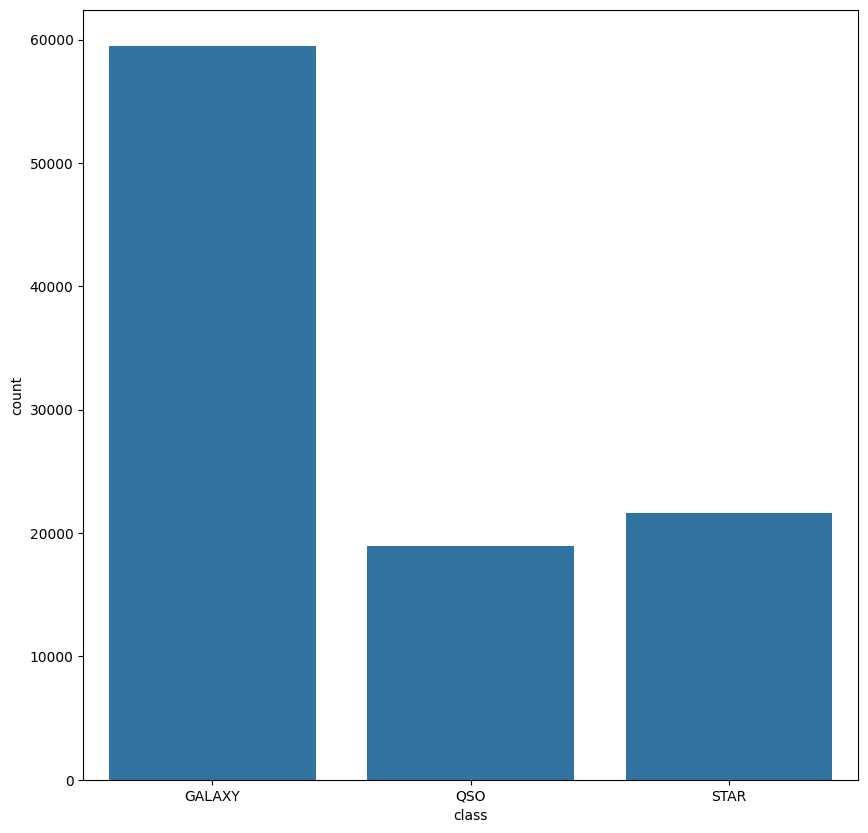

In [16]:
plt.figure(figsize=(10,10))
sns.countplot(data=df,x="class")

([<matplotlib.patches.Wedge at 0x231f376c980>,
 [Text(-0.3216272173789337, 1.051929623616088, 'GALAXY'),
  Text(-0.3239728375169962, -1.0512095892595283, 'STAR'),
  Text(0.9105456051052268, -0.6171763937672573, 'QSO')],
 [Text(-0.17543302766123656, 0.5737797946996842, '59%'),
  Text(-0.17671245682745243, -0.5733870486870154, '22%'),
  Text(0.49666123914830546, -0.3366416693275948, '19%')])

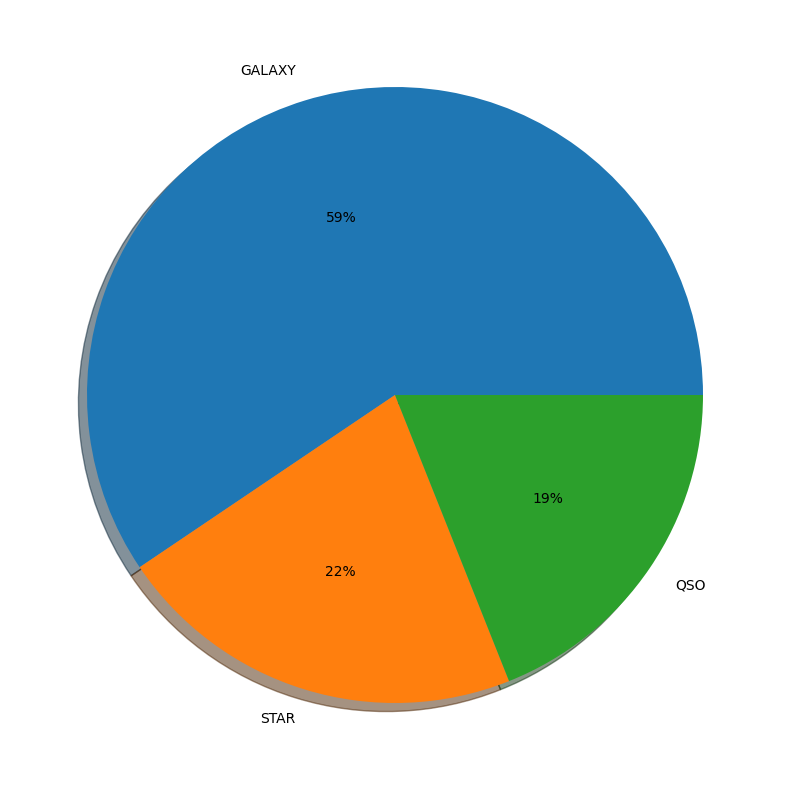

In [17]:
plt.figure(figsize=(10,10))
plt.pie(x=df['class'].value_counts(),labels=["GALAXY","STAR","QSO"],autopct="%1.f%%",shadow=True)

preprocessing & correlation matrix & feature selection

In [18]:
from sklearn.calibration import LabelEncoder
encoder=LabelEncoder()
df['class']=encoder.fit_transform(df['class'])

In [19]:
def plot(column,df):
    for i in range(3):
        sns.kdeplot(data=df[df["class"] == i][column], label = encoder.inverse_transform([i]), fill = True)
    sns.kdeplot(data=df[column],label = ["All"], fill = True)
    plt.legend();
    
def log_plot(column):
    for i in range(3):
        sns.kdeplot(data=np.log(df[df["class"] == i][column]), label = encoder.inverse_transform([i]), fill = True)
    sns.kdeplot(data=np.log(df[column]),label = ["All"], fill = True)
    plt.legend()

Text(0.5, 1.0, ' stellar correlation matrix')

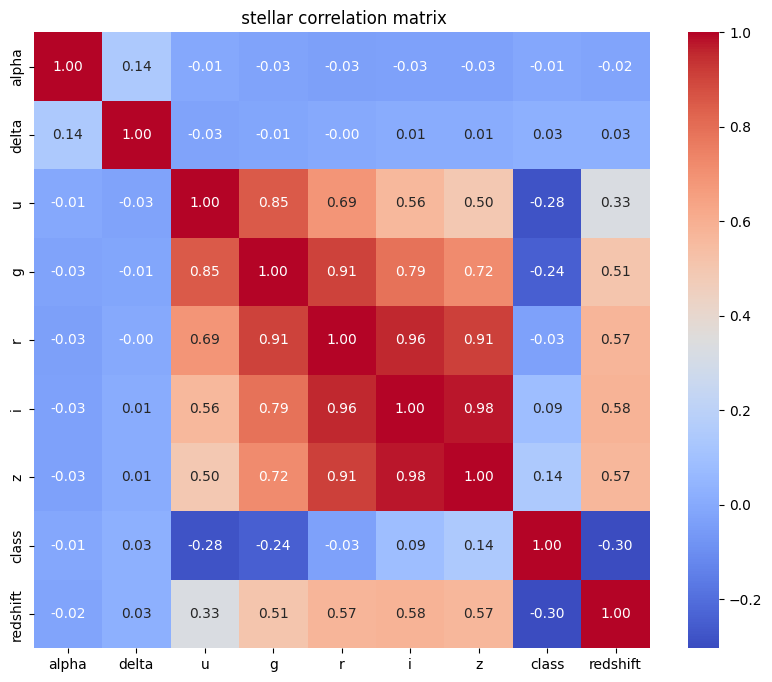

In [20]:
corr_matt=df.corr(method="spearman")
plt.figure(figsize=(10,8))
sns.heatmap(corr_matt,annot=True,fmt="0.2f",cmap="coolwarm",square=True)
plt.title(" stellar correlation matrix")

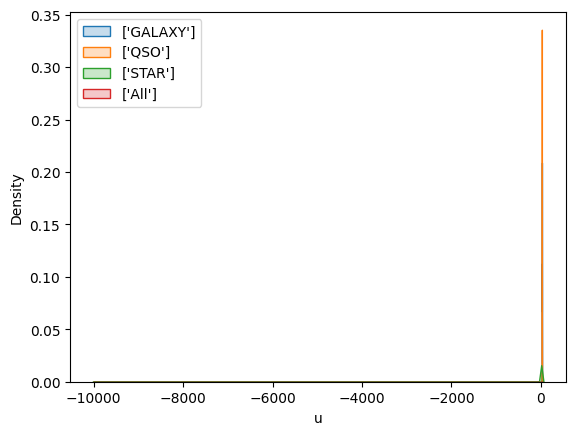

In [21]:
plot('u',df)

In [ ]:
#plot('g')

TypeError: plot() missing 1 required positional argument: 'df'

In [24]:
import pandas as pd
import numpy as np

def remove_outliers_iqr(df, cols=None, visualize=False):
    """
    Returns a copy of df with outliers removed using IQR method.
    Optionally specify columns; if none, all numeric columns are used.
    """
    df_clean = df.copy()
    original_shape = df.shape

    if cols is None:
        cols = df.select_dtypes(include='number').columns

    for col in cols:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    removed = original_shape[0] - df_clean.shape[0]
    print(f"Outliers removed: {removed} rows")

    return df_clean


In [25]:
# Remove outliers from the whole DataFrame (safe version)
clean_star = remove_outliers_iqr(df)

# Remove outliers only from specific columns
#clean_star = remove_outliers_iqr(star, cols=['u', 'g', 'r', 'i', 'z'])

# View how many rows were removed
print(f"After cleaning: {clean_star.shape}")


Outliers removed: 9400 rows
After cleaning: (90600, 9)


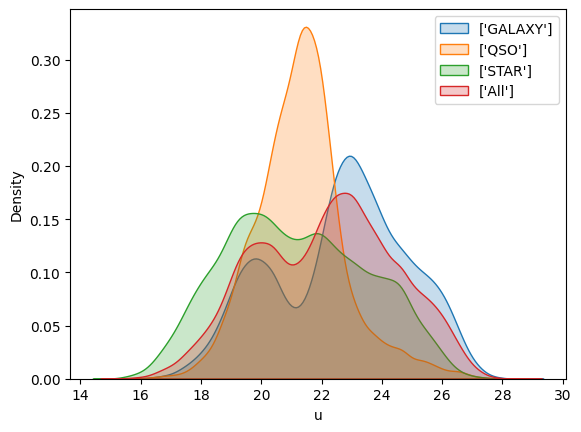

In [26]:
plot('u',clean_star)

In [27]:
x=clean_star.drop("class",axis=1)
y=clean_star['class']

In [28]:
scaler=StandardScaler()
x_scaler=scaler.fit_transform(x)

Train/Test split

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x_scaler,y,test_size=0.3,random_state=42)

In [30]:
x_train.shape


(63420, 8)

In [ ]:
y_train.shape

(63420,)

In [ ]:
x_test.shape

(27180, 8)

In [32]:
num_classes = len(np.unique(y))
print(num_classes)

3


training knn model 

In [ ]:
K = []
training = []
test = []
scores = {}

for k in range(2, 21):
    clf = KNeighborsClassifier(n_neighbors = k)
    clf.fit(x_train, y_train)

    training_score = clf.score(x_train, y_train)
    test_score = clf.score(x_test, y_test)
    K.append(k)

    training.append(training_score)
    test.append(test_score)
    scores[k] = [training_score, test_score]


evaluate the model 

In [ ]:
for keys, values in scores.items():
    print(keys, ':', values)


2 : [0.969284137496058, 0.9303899926416482]
3 : [0.9661147902869757, 0.9443340691685063]
4 : [0.960643330179754, 0.9416482707873436]
5 : [0.9600914538000631, 0.9442972774098601]
6 : [0.9565121412803532, 0.9420161883738043]
7 : [0.9559918006937874, 0.9430463576158941]
8 : [0.9532324187953327, 0.9400662251655629]
9 : [0.9532954903815831, 0.9413171449595291]
10 : [0.9510722169662567, 0.9388520971302429]
11 : [0.9505991800693787, 0.9403973509933775]
12 : [0.9488489435509303, 0.9385209713024283]
13 : [0.9489120151371807, 0.938962472406181]
14 : [0.9470040996531063, 0.9374172185430464]
15 : [0.9473825291706086, 0.9381162619573216]
16 : [0.9454746136865342, 0.9362398822663723]
17 : [0.9458845789971618, 0.9371596762325239]
18 : [0.9438347524440239, 0.936092715231788]
19 : [0.9445600756859035, 0.9357247976453275]
20 : [0.9427940712708924, 0.9350993377483444]


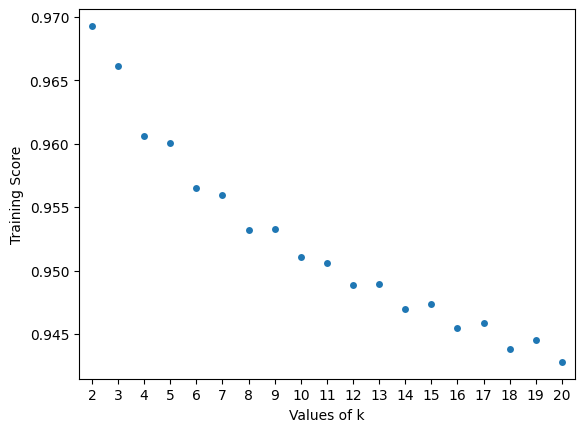

In [ ]:
ax = sns.stripplot(x=K, y=training)  # Use x and y as keyword arguments
ax.set(xlabel='Values of k', ylabel='Training Score')
plt.show()


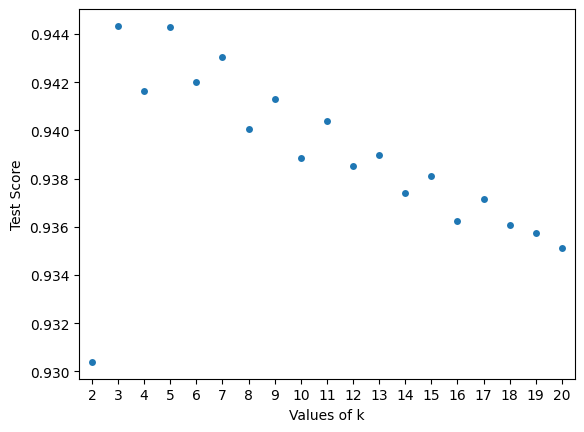

In [ ]:
ax = sns.stripplot(x=K, y=test)  # Use x and y as keyword arguments
ax.set(xlabel='Values of k', ylabel='Test Score')
plt.show()


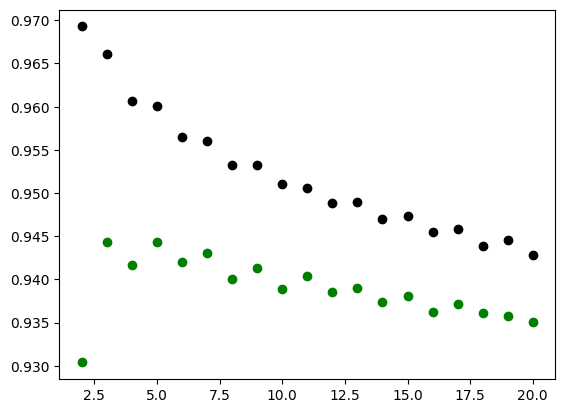

In [ ]:
plt.scatter(K, training, color='k')
plt.scatter(K, test, color='g')
plt.show()


logistic regression

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']})

In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
print("Best params:", grid_search.best_params_)
print(classification_report(y_test, y_pred))

Best params: {'C': 10, 'solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     17828
           1       0.89      0.78      0.83      2991
           2       0.97      1.00      0.98      6361

    accuracy                           0.96     27180
   macro avg       0.94      0.92      0.93     27180
weighted avg       0.96      0.96      0.96     27180



neural network 

In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # For multi-class classification
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

C:\Users\BIG BOX\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
history = model.fit(x_train, y_train, epochs=8, batch_size=30, validation_split=0.2, verbose=1)


Epoch 1/8
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9705 - loss: 0.0931 - val_accuracy: 0.9734 - val_loss: 0.0929
Epoch 2/8
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9717 - loss: 0.0905 - val_accuracy: 0.9733 - val_loss: 0.0922
Epoch 3/8
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9715 - loss: 0.0929 - val_accuracy: 0.9735 - val_loss: 0.0912
Epoch 4/8
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9718 - loss: 0.0905 - val_accuracy: 0.9742 - val_loss: 0.0909
Epoch 5/8
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9728 - loss: 0.0908 - val_accuracy: 0.9746 - val_loss: 0.0887
Epoch 6/8
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9712 - loss: 0.0902 - val_accuracy: 0.9748 - val_loss: 0.0887
Epoch 7/8
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9729 - loss: 0.0890 - val_accuracy: 0.9735 - val_loss: 0.0919
Epoch 8/8
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9720 - loss: 0.0900 - v

In [60]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9643 - loss: 0.1165
Test Accuracy: 96.73%


evaluation metrics

850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Accuracy: 0.9673289183222958
Precision: 0.9670271580647662
Recall: 0.9673289183222958
F1-Score: 0.9669082655620802


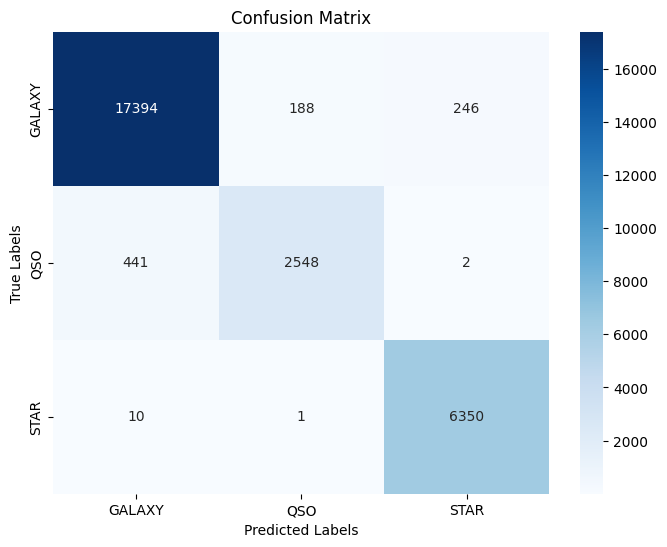

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # For multi-class problems

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')
cm = confusion_matrix(y_test, y_pred_classes)

# Print metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Confusion Matrix')
plt.show()


Training vs Validation Loss

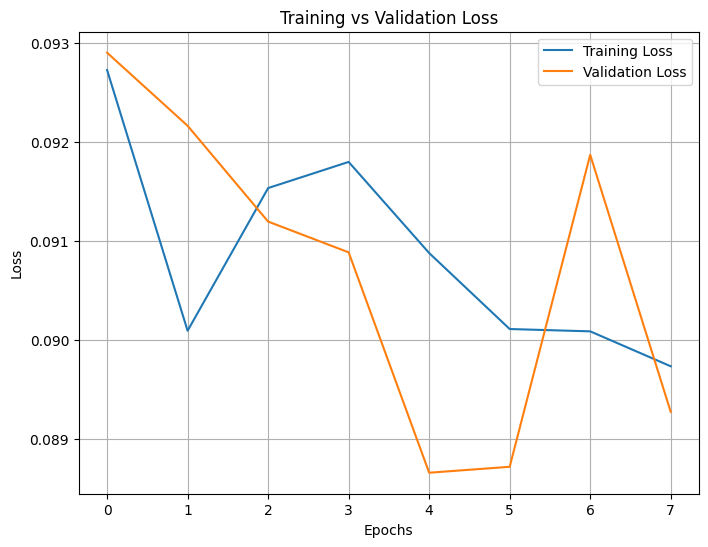

In [59]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

ROC curve


850/850 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


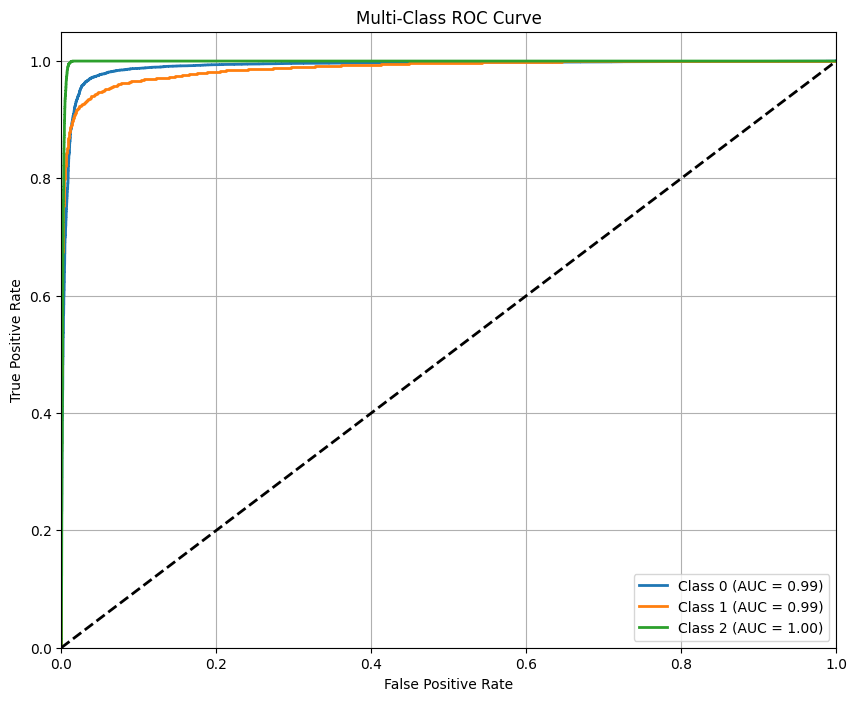

In [62]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Suppose you have these:
# y_test → your true labels (example: [0, 1, 2, 1, 0, 2, ...])
# y_pred_prob → model predicted probabilities for each class (not the predicted classes)

# Example: if you have 3 classes: galaxy (0), star (1), quasar (2)
n_classes = len(np.unique(y_test))

# Step 1: Binarize the labels
y_test_binarized = label_binarize(y_test, classes=list(range(n_classes)))
# Predict probabilities
y_pred_prob = model.predict(x_test)

# Step 2: Calculate ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 3: Plot all ROC curves
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot random line (diagonal)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()
